# 02 — Phân tích Khám phá Dữ liệu (EDA)

## Mục tiêu (Phần 2 của đề thi — 60 điểm)
Tạo visualizations và phân tích theo 4 cấp độ:
- **Descriptive**: What happened? — Thống kê tổng hợp
- **Diagnostic**: Why did it happen? — Phân tích nguyên nhân
- **Predictive**: What is likely to happen? — Xu hướng, tính mùa vụ
- **Prescriptive**: What should we do? — Đề xuất hành động kinh doanh

## Input
`data/processed/merged_orders.parquet`, `data/raw/sales.csv`, `data/raw/web_traffic.csv`, ...

## Output
Các biểu đồ export sang `figures/`

## Người phụ trách
_(Điền tên thành viên)_

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.append("..") # để import từ src/

from src.ui_builder.data_viz import *

PROCESSED = Path("../data/processed")
FIGURES   = Path("../figures")

# Load các bảng đã xử lý ở preprocessing
fact_sales    = pd.read_csv(PROCESSED / "fact_sales_daily.csv", parse_dates=["date"])
fact_orders   = pd.read_csv(PROCESSED / "fact_orders_enriched.csv", parse_dates=["order_date"])
fact_returns  = pd.read_csv(PROCESSED / "fact_returns_enriched.csv", parse_dates=["return_date", "order_date"])
fact_inv      = pd.read_csv(PROCESSED / "fact_inventory.csv")
agg_monthly   = pd.read_csv(PROCESSED / "agg_monthly_summary.csv")
agg_cohort    = pd.read_csv(PROCESSED / "agg_cohort_retention.csv")
dim_customers = pd.read_csv(PROCESSED / "dim_customers_rfm.csv")
dim_products  = pd.read_csv(PROCESSED / "dim_products.csv")

C:\Users\USER\AppData\Local\Temp\ipykernel_30512\2321015484.py:15: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  fact_orders   = pd.read_csv(PROCESSED / "fact_orders_enriched.csv", parse_dates=["order_date"])


In [4]:
total_revenue = fact_sales["revenue"].sum()
gross_profit  = fact_sales["gross_profit"].sum()
gross_margin  = (gross_profit / total_revenue * 100).round(2)
total_orders  = fact_orders["order_id"].nunique()
total_customers = dim_customers["customer_id"].nunique()

print(f"Total Revenue    : {total_revenue/1e9:.2f}B")
print(f"Gross Profit     : {gross_profit/1e9:.2f}B")
print(f"Gross Margin     : {gross_margin}%")
print(f"Total Orders     : {total_orders:,}")
print(f"Total Customers  : {total_customers:,}")

Total Revenue    : 16.43B
Gross Profit     : 2.27B
Gross Margin     : 13.8%
Total Orders     : 646,945
Total Customers  : 121,930


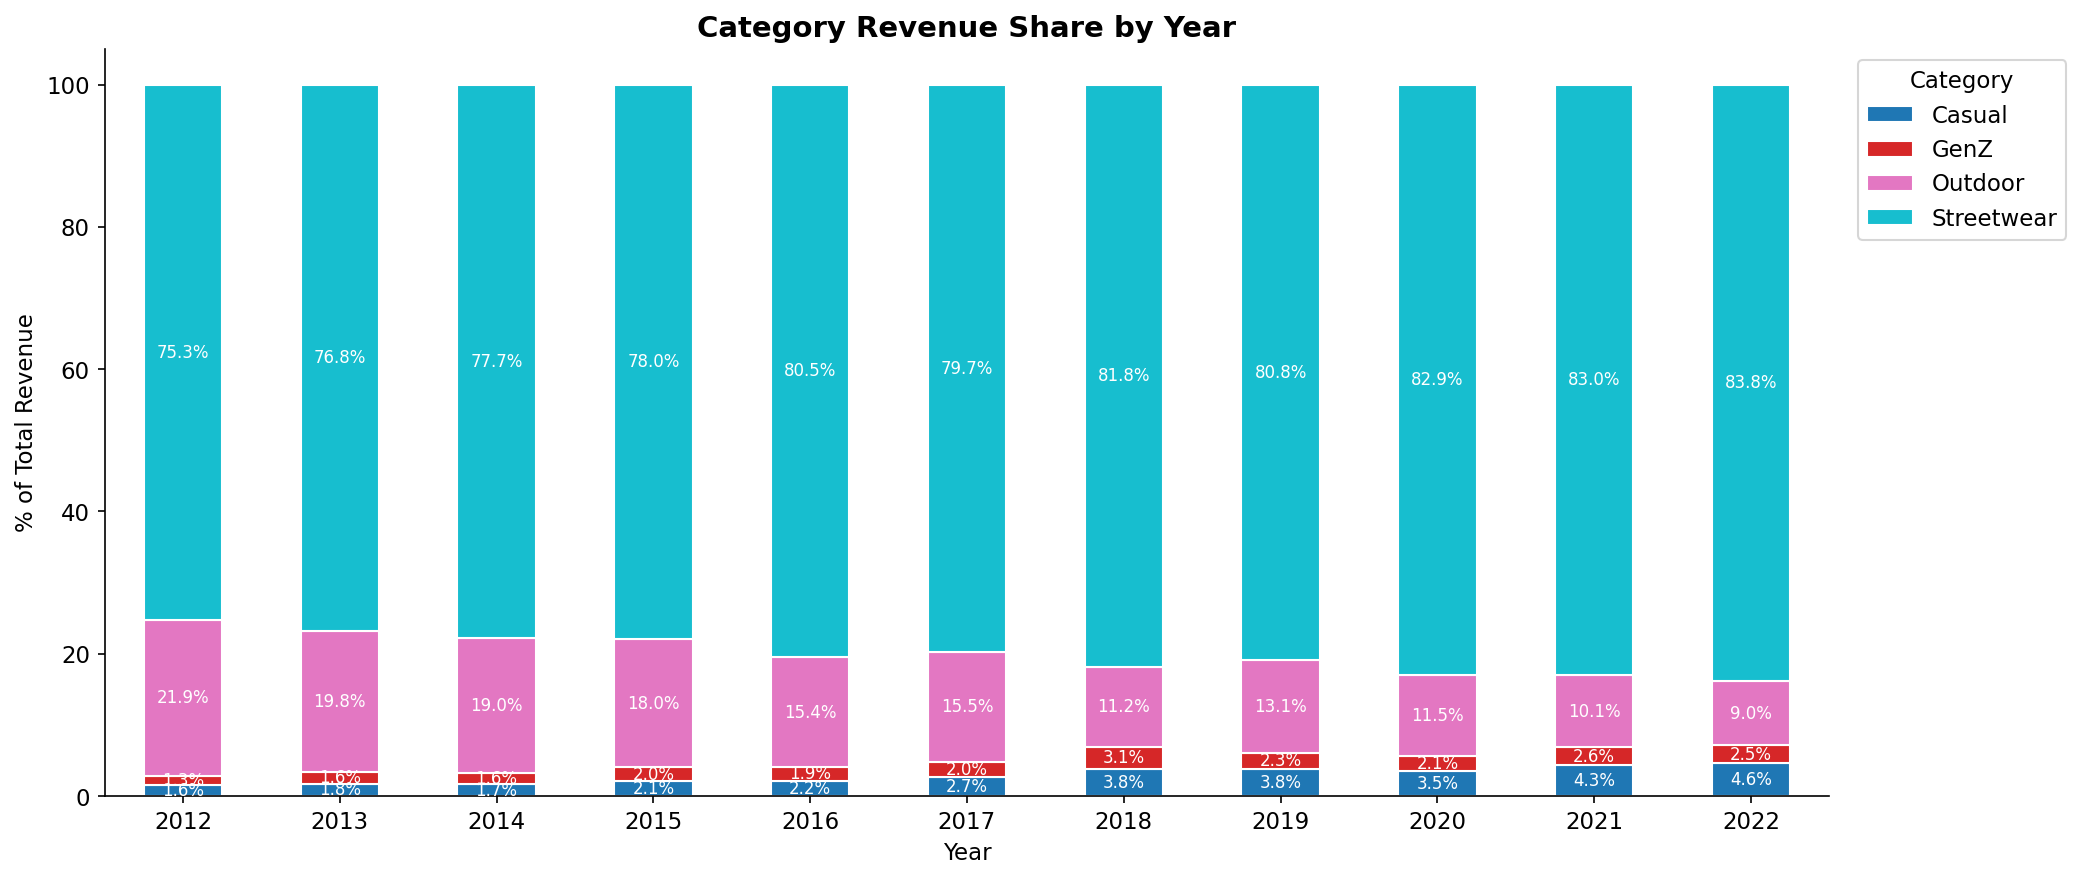

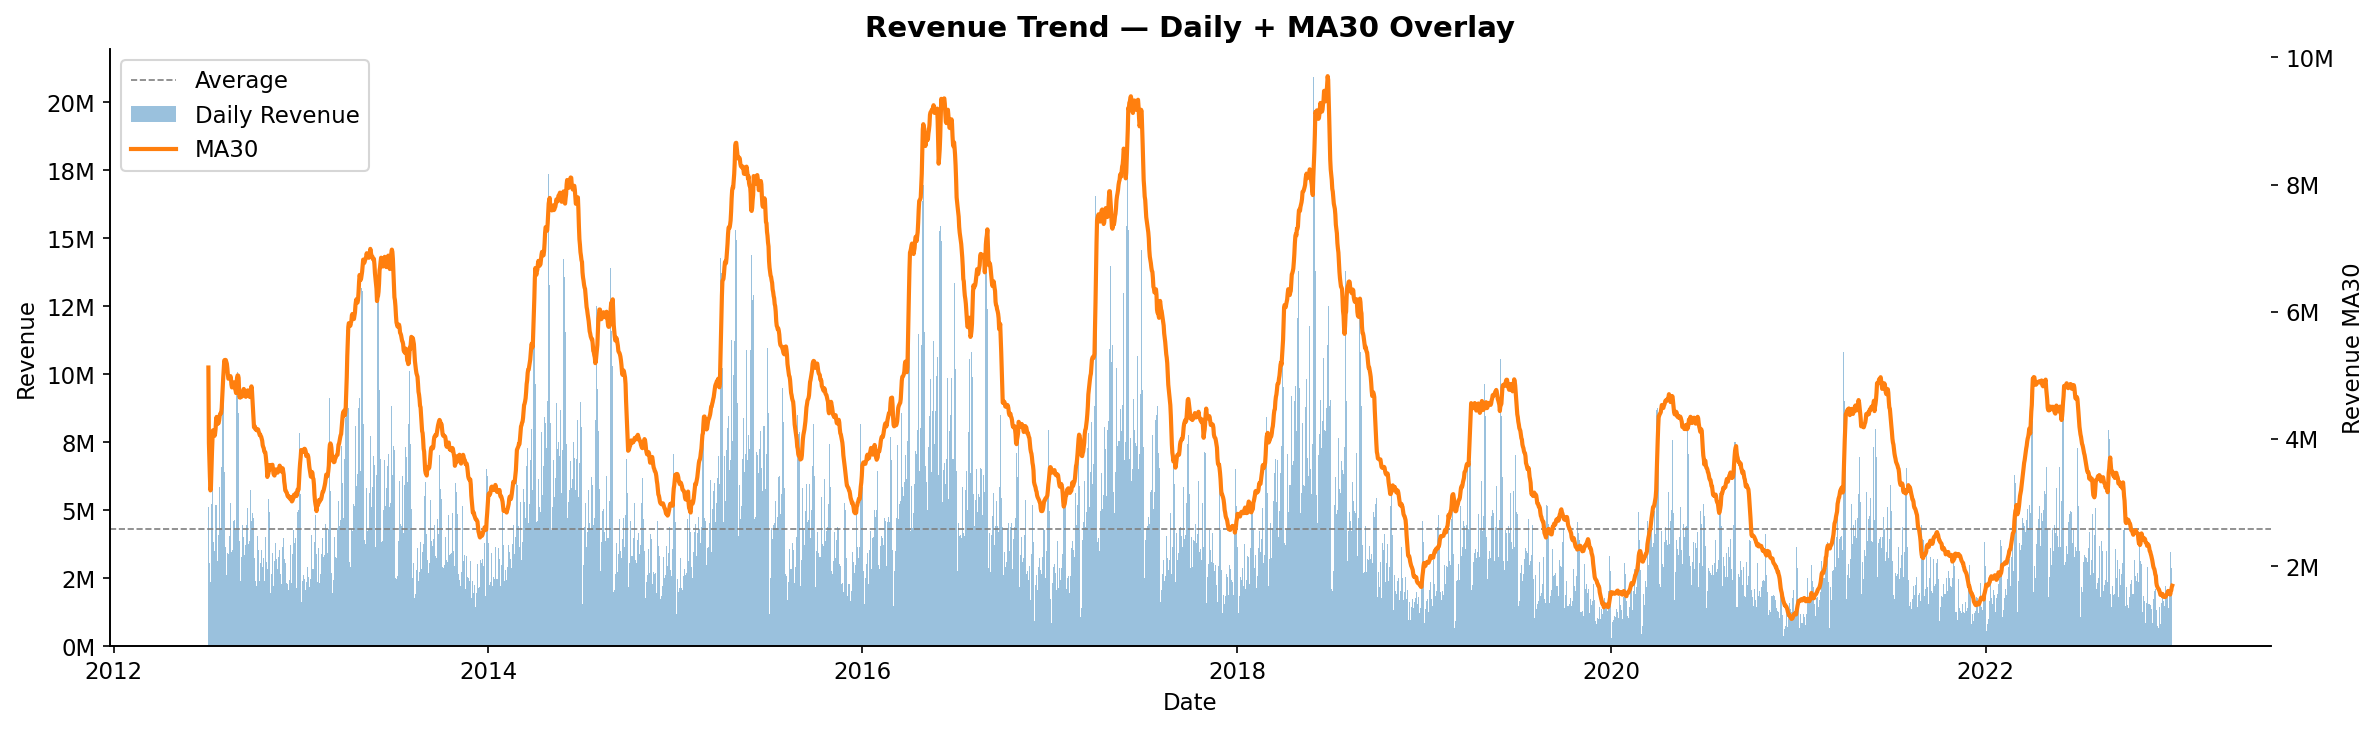

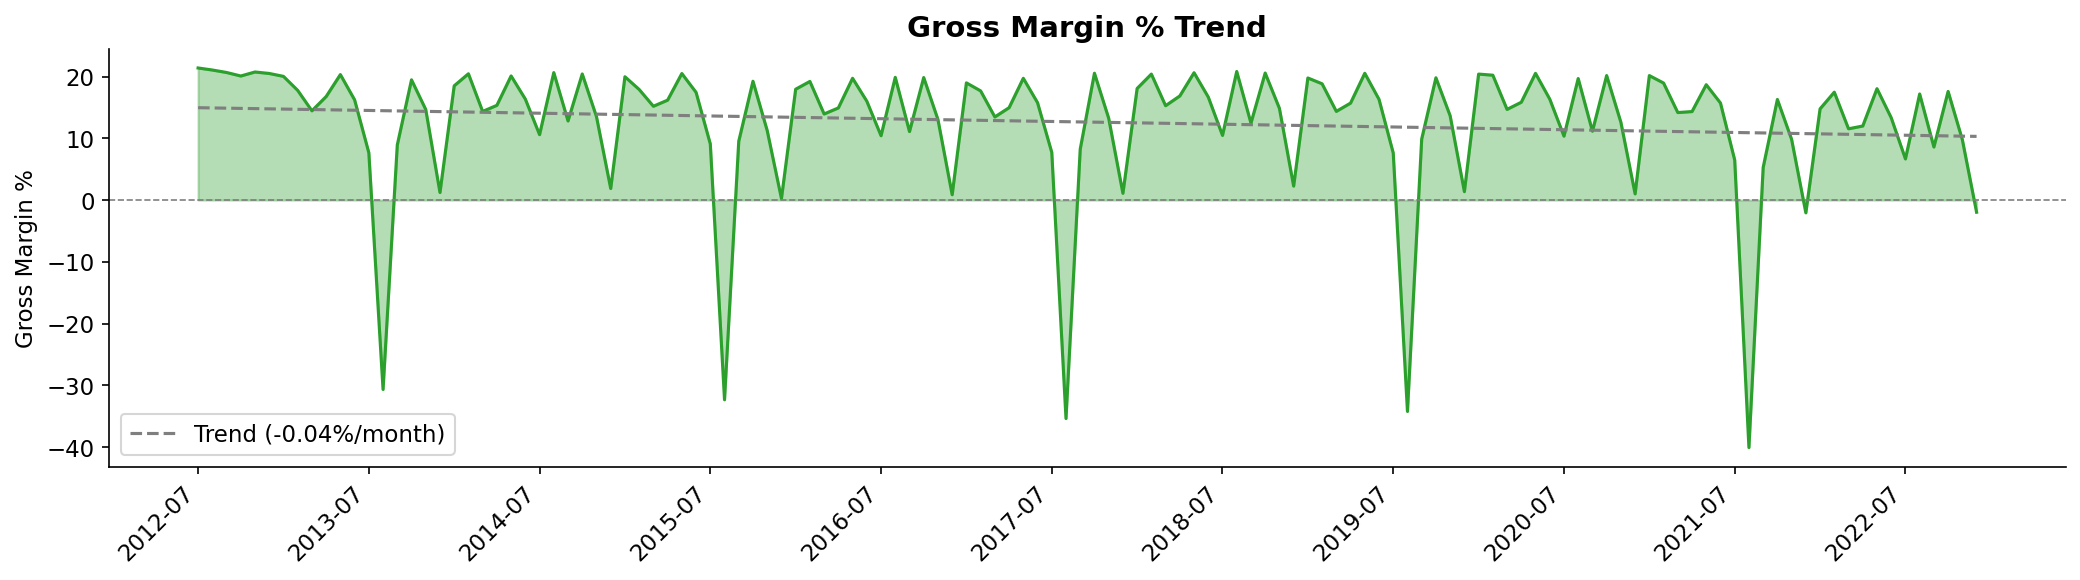

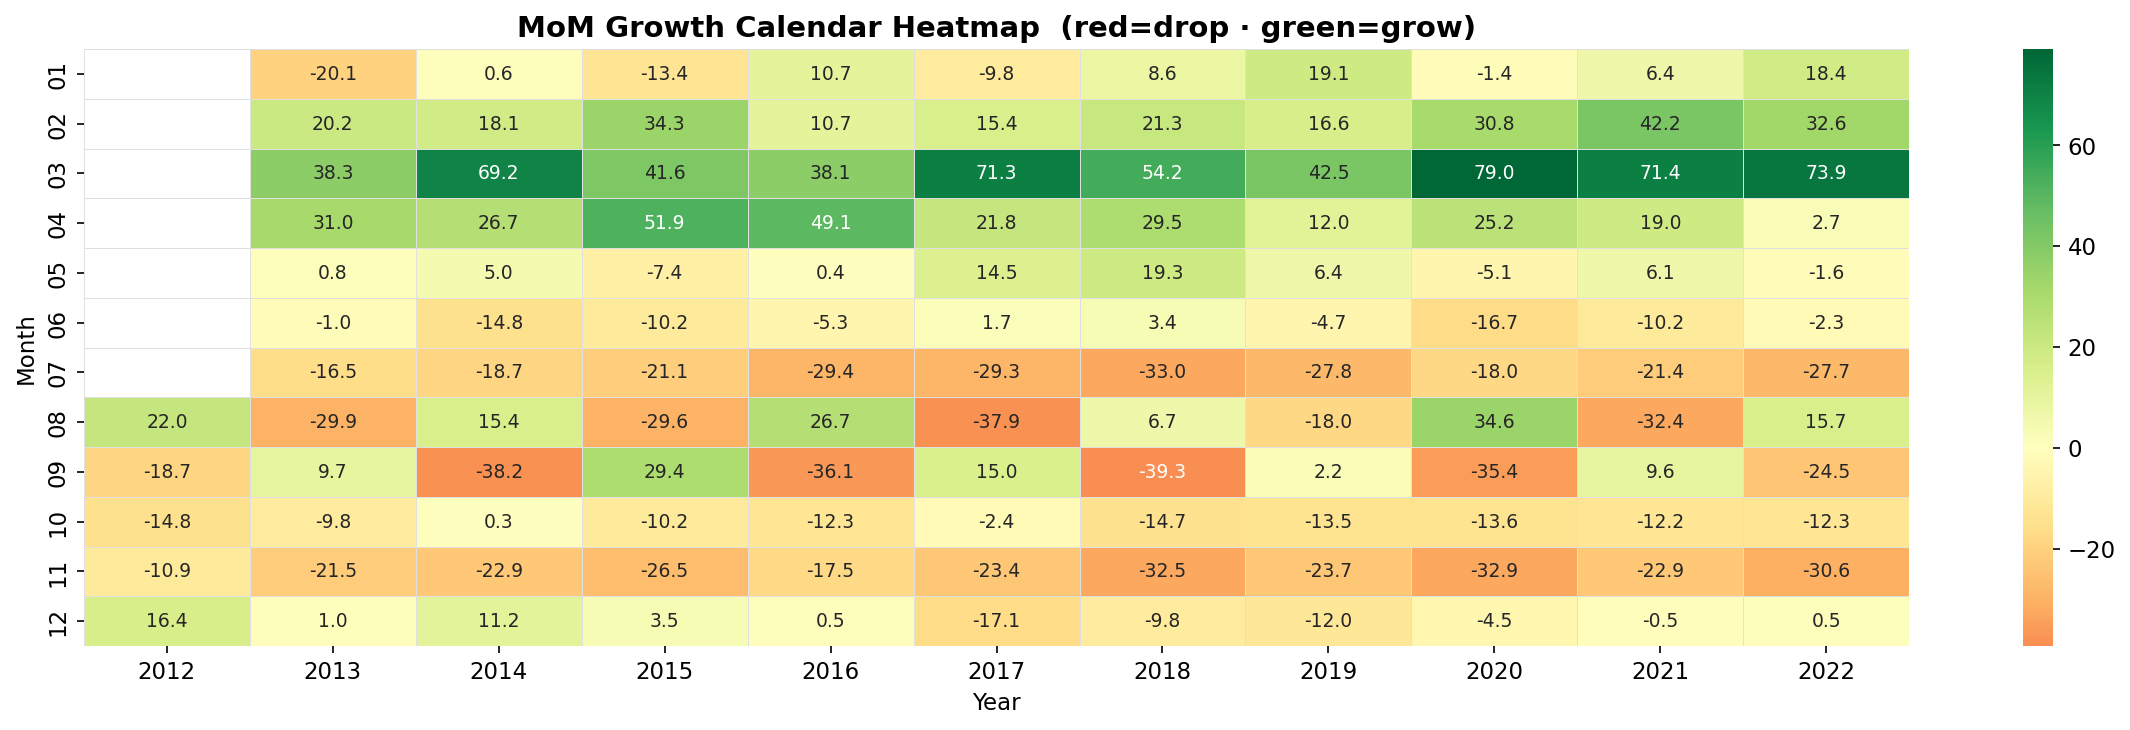

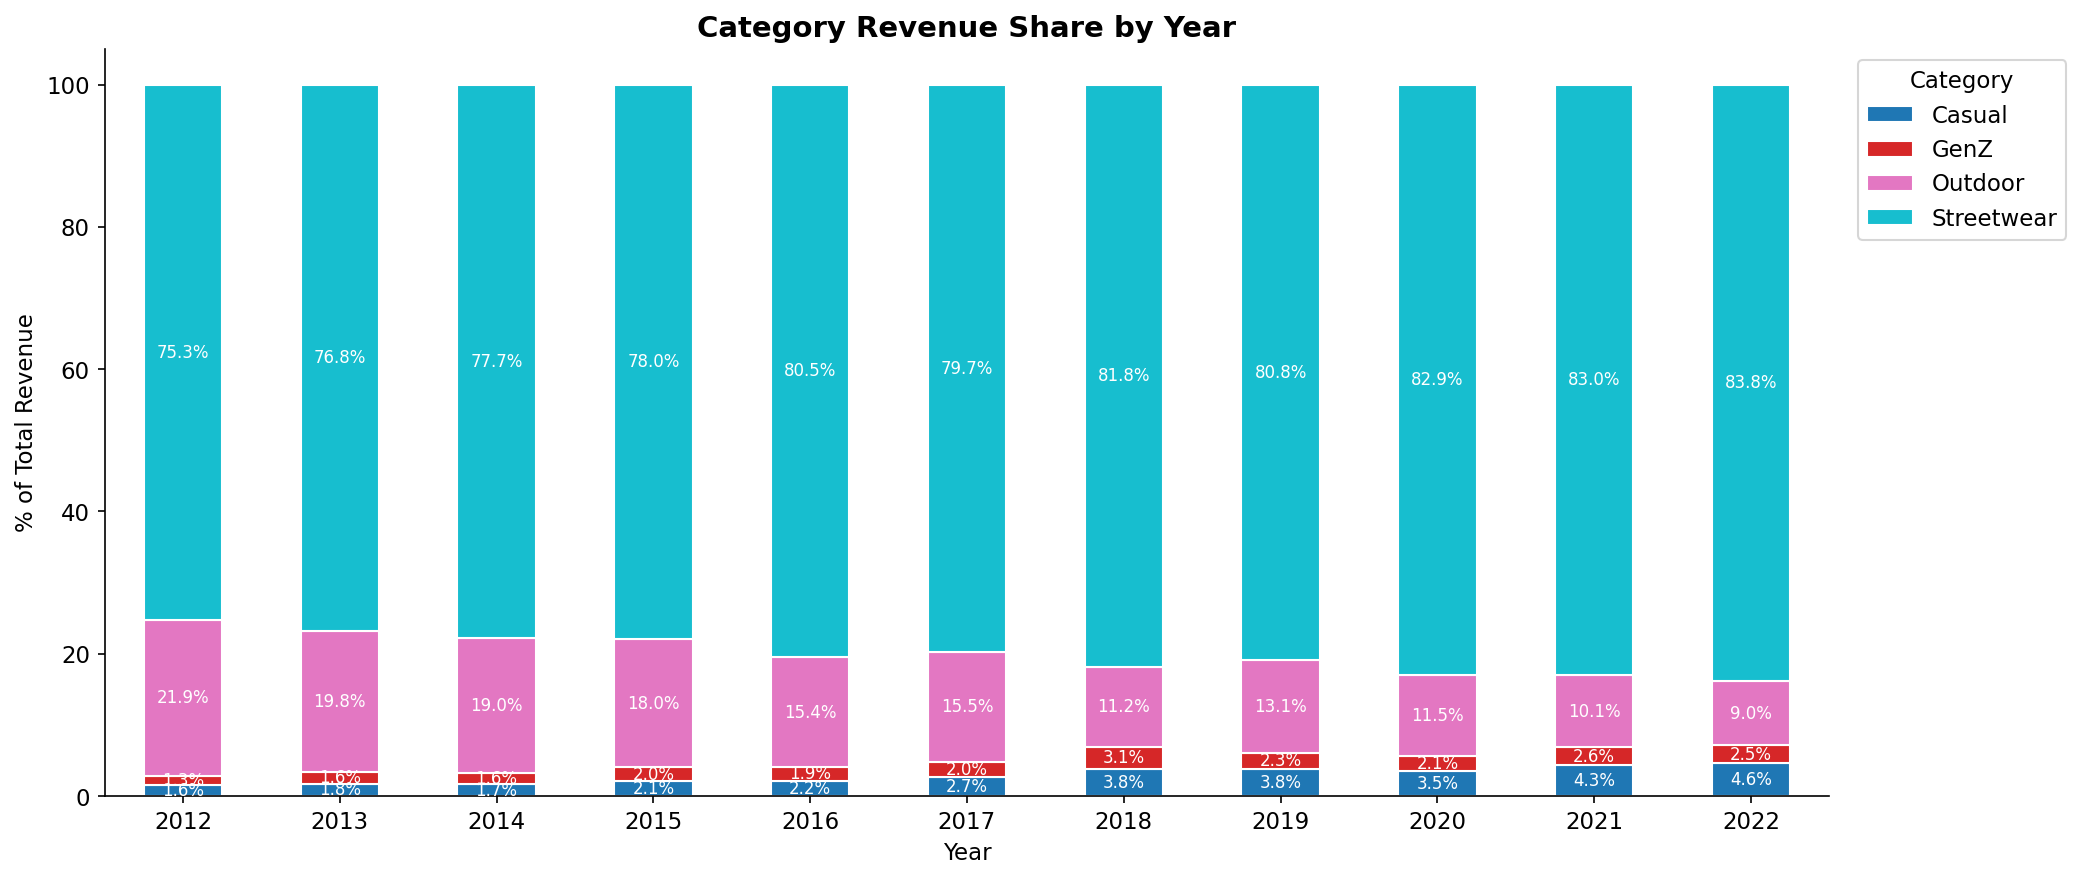

In [6]:
# D1_01: Revenue trend hàng ngày + MA30
plot_revenue_trend(fact_sales, save_path=FIGURES / "D1_01_revenue_trend.png")

# D1_02: Gross margin % theo tháng
plot_gross_margin_trend(agg_monthly, save_path=FIGURES / "D1_02_margin_trend.png")

# D1_03: MoM growth heatmap
plot_mom_heatmap(agg_monthly, save_path=FIGURES / "D1_03_mom_heatmap.png")

# D1_04: Category revenue share by year
plot_category_breakdown(fact_orders, save_path=FIGURES / "D1_04_category_share.png")